In [ ]:
!apt-get update
from google.colab import drive

# Use the 'force_remount' parameter to refresh credentials
drive.mount('/drive/', force_remount=True)

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Ign:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,027 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy Release [5,713 B]
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy Release.gpg [793 B]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd6

In [ ]:
!pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.2/553.2 kB 32.5 MB/s eta 0:00:00


In [ ]:
import stanza
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from string import punctuation

nltk.download('punkt')
stanza.download('tr')
nlp = stanza.Pipeline('tr')
csv_file_path = '/drive/MyDrive/sade.xlsx'
df = pd.read_excel(csv_file_path)
column_name = 'model1_wrong'
texts = df[column_name].dropna().tolist()

def filter_tokens(tokens):
        return [token for token in tokens if token not in punctuation and len(token) > 1]

def calculate_tree_depth(sentence):
    doc = nlp(sentence)
    depths = []

    for sent in doc.sentences:
         depths.extend([get_depth(word, sent) for word in sent.words])

    if len(depths) > 0:
        return max(depths)
    return 0

def get_depth(word, sentence):

    if word.head == 0:
        return 1
    else:
        head_word = sentence.words[word.head - 1]
        return 1 + get_depth(head_word, sentence)

depths = [calculate_tree_depth(text) for text in texts]

# ortalamasını hesapla
average_depth = np.mean(depths)

print(f"Dependency Tree Depths: {depths}")
print(f"Average Dependency Tree Depth: {average_depth}")
# list=[6, 7, 3, 5, 6, 5, 6, 6, 6, 8, 4, 5, 5, 3, 5, 7, 5, 4, 5, 6, 6, 6, 4, 2, 5, 5, 4, 5, 5, 3, 5, 4, 5, 3, 5, 5, 4, 2, 5, 5, 6, 4, 4, 7, 3, 6, 5, 6, 6, 4, 5, 5, 3, 3, 4, 3, 4, 4, 5, 7, 5, 4, 5, 3, 6, 6, 5, 4, 4, 6, 5, 4, 5, 3, 7, 4, 4, 3, 3, 3, 7, 4, 6, 3, 6, 3, 5, 3, 5, 5, 5, 3, 5, 6, 3, 4, 4, 4, 4, 5]
# print(len(list))



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: tr (Turkish) ...
INFO:stanza:File exists: /root/stanza_resources/tr/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: tr (Turkish):
| Processor | Package       |
-----------------------------
| tokenize  | imst          |
| mwt       | imst          |
| pos       | imst_charlm   |
| lemma     | imst_nocharlm |
| depparse  | imst_charlm   |
| ner       | starlang      |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
/usr/local/lib/python3.10/dist-packages/stanza/models/tokenization/trainer.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during

Dependency Tree Depths: [5, 5, 3, 5, 5, 4, 6, 4, 8, 8, 5, 6, 6, 3, 5, 6, 4, 4, 4, 6, 5, 6, 4, 3, 6, 4, 4, 4, 4, 3, 5, 4, 6, 4, 4, 4, 4, 2, 6, 5, 5, 6, 4, 7, 3, 3, 5, 4, 6, 3, 6, 5, 4, 3, 4, 5, 6, 6, 7, 5, 7, 4, 5, 4, 6, 8, 4, 4, 4, 7, 5, 6, 6, 3, 6, 5, 4, 5, 3, 3, 7, 3, 5, 3, 5, 4, 4, 3, 5, 6, 6, 3, 4, 8, 5, 5, 5, 4, 6, 4]
Average Dependency Tree Depth: 4.8


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: tr (Turkish) ...
INFO:stanza:File exists: /root/stanza_resources/tr/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: tr (Turkish):
| Processor | Package       |
-----------------------------
| tokenize  | imst          |
| mwt       | imst          |
| pos       | imst_charlm   |
| lemma     | imst_nocharlm |
| depparse  | imst_charlm   |
| ner       | starlang      |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
/usr/local/lib/python3.10/dist-packages/stanza/models/tokenization/trainer.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during

Span Lengths: [118, 84, 38, 103, 79, 56, 83, 111, 103, 133, 45, 66, 88, 39, 58, 130, 104, 67, 80, 137, 87, 84, 64, 29, 94, 129, 63, 60, 69, 48, 86, 61, 103, 62, 65, 57, 51, 37, 57, 80, 64, 77, 31, 112, 33, 76, 107, 96, 97, 63, 84, 77, 52, 65, 77, 53, 77, 85, 84, 205, 52, 67, 105, 57, 73, 112, 119, 84, 60, 129, 80, 77, 70, 33, 95, 107, 67, 60, 51, 49, 105, 60, 88, 76, 71, 42, 64, 37, 56, 87, 52, 72, 60, 67, 63, 71, 98, 77, 54, 75]
Average Span Length: 76.45
100


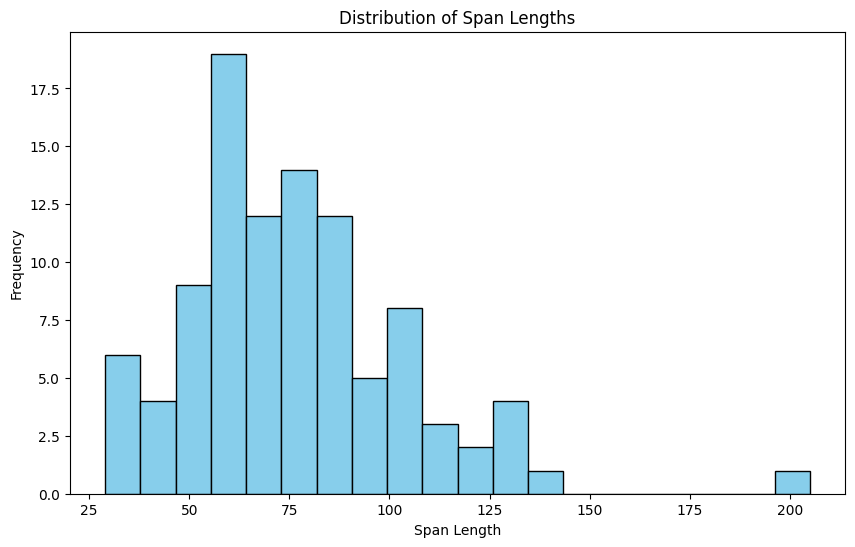

In [ ]:
import stanza
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from string import punctuation

nltk.download('punkt')
stanza.download('tr')
nlp = stanza.Pipeline('tr')
csv_file_path = '/drive/MyDrive/sade.xlsx'
df = pd.read_excel(csv_file_path)
column_name = 'model1_correct'
texts = df[column_name].dropna().tolist()

def filter_tokens(tokens):
    return [token for token in tokens if token not in punctuation and len(token) > 1]

def calculate_span_length(sentence):
    doc = nlp(sentence)

    span_lengths = []
    for sent in doc.sentences:

        start_indices = [word.start_char for word in sent.words if word.start_char is not None]
        end_indices = [word.end_char for word in sent.words if word.end_char is not None]

        if len(start_indices) > 0 and len(end_indices) > 0:
            span_length = max(end_indices) - min(start_indices)
            span_lengths.append(span_length)

    if len(span_lengths) > 0:
        return max(span_lengths)
    return 0
span_lengths = [calculate_span_length(text) for text in texts]


average_span_length = np.mean(span_lengths)

print(f"Span Lengths: {span_lengths}")
print(f"Average Span Length: {average_span_length}")
# list=[83, 94, 39, 92, 116, 52, 84, 85, 120, 129, 57, 89, 98, 49, 77, 91, 73, 85, 84, 132, 83, 82, 69, 34, 91, 91, 42, 52, 73, 38, 84, 48, 85, 70, 80, 51, 55, 35, 61, 83, 75, 85, 44, 104, 32, 56, 104, 75, 52, 47, 100, 98, 31, 69, 74, 61, 88, 87, 92, 100, 64, 51, 82, 40, 80, 139, 82, 82, 69, 139, 85, 84, 62, 33, 66, 80, 44, 43, 43, 47, 98, 58, 102, 62, 99, 60, 50, 43, 55, 85, 58, 78, 61, 120, 70, 71, 105, 73, 52, 64]


